## Part C1.2. Computing Nematic order using TrackMate-extracted spot data
#### The objective of this jupyter notebook is to extract the relative orientation of single cells to compute the nematic order for each condition. The data processing was based on the segmented masks retrieved using Onimpose in Part A. 

#### Subsequently, we applied TrackMate using the same methods described in Part B (specifically using the label image detect) to analyze the information of cells (spots) in the colony. It is noted that the properties of the mask was set with 0.065 um pixel size and 5-second frame interval. The TrackMate-extracted CSV file for each condition was save and directly perform batch processing.

In [1]:
#Import essential libraries 
import pandas as pd
import numpy as np
import os

"""
Perform batch processing for multiple CSV files corresponding to different mutants and densities.
This code will finally save the results in a single CSV file that includes 
all the Nematic order values for all 9 conditions 
"""
# Define the directory where the CSV files are located. It's noted that this depends on the data storage of the user
data_directory = '/Users/herbert/Desktop/ME480/Projects/Project1/Data/Trackmate_output/All'

# Obtain a list of all CSV files in the directory using os.listdir()
file_names = [f for f in os.listdir(data_directory) if f.endswith ('csv')]

### Define the functions to calculate the Nematic Order
#### Equation1: *Sr_1 = <P(cos(theta)> = <1/2*(3cos^2(theta)-1)>, computing the para nematic order1*
#### Equation2: *Sr_2 = =<cos[2(θ_i−ϕ_i)]>, computing the para nematic order2*

In [3]:
# Define function to calculate the Nematic order, which is defined based on the average of the second Legendre polynomial:
def calculate_nematic_order1 (orientations):
    #Compute the nematic order using the formula described above
    cos_theta = np.cos(orientations)
    nematic_order = np.mean ((3 * cos_theta**2 -1)/2)
    return nematic_order

# Define another function to calculate the Nematic order, accroding to the publication (Basaran, et al., 2022)
def calculate_nematic_order2 (theta, phi):
    """
    Calculates the nematic order parameter S_R for a group of cells (i).
    
    :param theta: Array of angular orientations (theta_i) in radians
    :param phi: Array of angular positions (phi_i) in radians (polar coordinates about colony center)
    :return: Nematic order parameter (S_R)
    """
    diff = theta - phi  # Difference between theta_i and phi_i
    nematic_order = np.mean(np.cos(2 * diff))
    return nematic_order

# Function to calculate polar angle (phi) from X and Y coordinates
def calculate_phi(x, y, center_x, center_y):
    """
    Calculates the polar angle phi_i for each bacterium relative to the colony center.
    
    :param x: X-coordinate of bacterium
    :param y: Y-coordinate of bacterium
    :param center_x: X-coordinate of the colony center
    :param center_y: Y-coordinate of the colony center
    :return: Array of phi_i values (in radians)
    """
    return np.arctan2(y - center_y, x - center_x)  # Calculate phi_i using arctan2 for full 360° coverage



### C1.2.1. Calculate the Nematic Order of the Whole Region for All Frame: 

In [12]:
# Initialize an empty list to hold the results
all_results = []

# Group the data by time and calculate nematic order for each time frame
nematic_order_per_timeframe = []

# Loop over each CSV file, process it and calcualate its Nematic Order
for file_name in file_names:
    file_path = os.path.join(data_directory, file_name)
    #reads the entire file but aviod guessing data types based on partial chunks
    data = pd.read_csv(file_path, low_memory = False)

    #To handle the Trackmate-extracted data
    #Ensure all columns are numeric, forcing non-numeric to NaN
    data['POSITION_X'] = pd.to_numeric(data['POSITION_X'], errors='coerce')
    data['POSITION_Y'] = pd.to_numeric(data['POSITION_Y'], errors='coerce')
    data ['POSITION_T'] = pd.to_numeric (data['POSITION_T'], errors = 'coerce')
    data ['ELLIPSE_THETA'] = pd.to_numeric (data['ELLIPSE_THETA'], errors = 'coerce')

    # Drop rows with NaN values (due to non-numeric entries)
    data = data.dropna(subset=['POSITION_X','POSITION_Y','POSITION_T','ELLIPSE_THETA'])

    # Inspect the first few rows of the data (optional)
    #print(data.head())
    
    # Process each Time frame in the CSV file 
    # Group data by Time (sec) and apply the calculation for each group
    for timeframe, group in data.groupby('POSITION_T'): # The name for the columne of Time 
        x_coords = group ['POSITION_X'].values # X coordinates in um
        y_coords = group ['POSITION_Y'].values # Y coordinates in um
        
        center_x = np.mean (x_coords)
        center_y = np.mean (y_coords)
        # print the colony center (optional)
        # print ('colony center (x,y):' , center_x, ",", center_y) 
        
        #Extract the 'Ellipse angle' values for each time frame 
        theta_values = group ['ELLIPSE_THETA'].values # The name for the columne of Ellipse angle

        phi_values = calculate_phi(x_coords, y_coords, center_x, center_y)

        # Using euqation 1 to calculate nematic order1
        nematic_order1 = calculate_nematic_order1 (theta_values)
        
        # Using equation 2 to calculate nematic order2
        nematic_order2 = calculate_nematic_order2 (theta_values, phi_values)

        # Append the reulst with condition name, Time , and Nematic order
        condition_name = file_name.split('.')[0] #Extract the condition name from the file name
        # Store the result as a tuple (position_T (time), nematic order)    
        all_results.append((condition_name, timeframe, nematic_order1, nematic_order2))
    
# Convert the results to a pandas DataFrame for saving
final_df = pd.DataFrame (all_results, columns=['Condition', 'Timeframe', 'Nematic Order1','Nematic Order2'])

# Demonstrate the results from calculation (optional)
# print("Sr_calculated as", all_results)

# Save the results to a new CSV file
output_file = '1_Sr_whole_frame.csv' #The file name should be changed based on the experimental dataset 
final_df.to_csv(output_file, index=False)

print("Nematic order for all conditions calculated and saved to", output_file)

Nematic order for all conditions calculated and saved to 1_Sr_whole_frame.csv


### C.1.2.2. Calculate the Nematic Order of the Region of Interest using **Region Filter**

#### From the previous calculation (C1.2.1.), we noticed that the calculated Numatic order for the whole region might create some problems in estimating the resutls.

#### From what we have learned in the leacture, calculating Numatic Order should be defined to a certain region that only considers such an order parameter among the neighbouring bacteria. The next two methods aim to initiatelly define a certain region in a relatively close proximity before calculating the Numatic order, so as to improve the accuratcy of the caulcation.

#### This part aims at first defining the region of interest (ROI).We divided the field of view into ROI in 4 quadrants and compuate the nematic order within each region by dividing the 133x133 um field into 4 quadrants. For each region, the data was filtered based on X and Y coordinates to restrict the nematic order calculation to cells within these regions. 

In [13]:
fov_size = 133.0  # Field of view size in µm (133x133 µm)
half_fov = fov_size / 2  # 66.5 µm, used for quadrant splitting

# Step 4: Define function to filter cells by region
def filter_by_region(data, region):
    """
    Filters cells based on their X, Y coordinates to fit within a given region (quadrant).
    
    :param data: Pandas DataFrame containing X, Y, and Theta columns
    :param region: String indicating the region ('Q1', 'Q2', 'Q3', 'Q4')
    :return: Filtered DataFrame containing only cells within the region
    """
    if region == 'Q1':  # Top-left
        return data[(data['POSITION_X'] < half_fov) & (data['POSITION_Y'] >= half_fov)]
    elif region == 'Q2':  # Top-right
        return data[(data['POSITION_X'] >= half_fov) & (data['POSITION_Y'] >= half_fov)]
    elif region == 'Q3':  # Bottom-left
        return data[(data['POSITION_X'] < half_fov) & (data['POSITION_Y'] < half_fov)]
    elif region == 'Q4':  # Bottom-right
        return data[(data['POSITION_X'] >= half_fov) & (data['POSITION_Y'] < half_fov)]
    else:
        return pd.DataFrame()  # Return empty DataFrame if region is invalid

# Step 5: Initialize an empty list to hold the results
all_results = []

# Step 6: Loop over each CSV file, process it, and calculate Nematic order for each quadrant
for file_name in file_names:
    file_path = os.path.join(data_directory, file_name)  # Get full file path
    data = pd.read_csv(file_path, low_memory=False)  # Read CSV with low_memory=False

    # Ensure all columns are numeric, forcing non-numeric to NaN
    data['POSITION_X'] = pd.to_numeric(data['POSITION_X'], errors='coerce')
    data['POSITION_Y'] = pd.to_numeric(data['POSITION_Y'], errors='coerce')
    data['POSITION_T'] = pd.to_numeric(data['POSITION_T'], errors='coerce')
    data['ELLIPSE_THETA'] = pd.to_numeric(data['ELLIPSE_THETA'], errors='coerce')

    # Drop rows with NaN values (due to non-numeric entries)
    data = data.dropna(subset=['POSITION_X', 'POSITION_Y', 'POSITION_T','ELLIPSE_THETA'])

    # Process each frame in the CSV file
    for timeframe, group in data.groupby('POSITION_T'):

        x_values = group ['POSITION_X'].values
        y_values = group ['POSITION_Y'].values
        theta_values = group['ELLIPSE_THETA'].values
        
        # Loop through each quadrant and calculate nematic order for cells in that quadrant
        for quadrant in ['Q1', 'Q2', 'Q3', 'Q4']:
             # Define the colony center based on the quadrant, given that (0,0) is at bottom left corner for TrackMate-based data
            if quadrant == 'Q1':
                center_x = half_fov / 2  # Center for Q1 (top-left)
                center_y = (3 * half_fov) / 2
            elif quadrant == 'Q2':
                center_x = (3 * half_fov) / 2  # Center for Q2 (top-right)
                center_y = (3 * half_fov) / 2
            elif quadrant == 'Q3':
                center_x = half_fov / 2  # Center for Q3 (bottom-left)
                center_y = half_fov / 2
            elif quadrant == 'Q4':
                center_x = (3 * half_fov) / 2  # Center for Q4 (bottom-right)
                center_y = half_fov / 2
            filtered_data = filter_by_region(group, quadrant)

            # Only calculate Nematic order if there are cells in the quadrant
            if len(filtered_data) > 0:
                theta_values = filtered_data['ELLIPSE_THETA'].values  # Orientation (Theta)

                #Calculate phi for each cell relative to colony center
                phi_values = calculate_phi(filtered_data['POSITION_X'].values, filtered_data['POSITION_Y'].values, center_x, center_y)

                nematic_order1 = calculate_nematic_order1 (theta_values)
                nematic_order2 = calculate_nematic_order2 (theta_values, phi_values)
            else:
                nematic_order1 = np.nan  # If no cells, set as NaN
                nematic_order2 = np.nan
            
            # Append the result with condition name, frame, quadrant, and Nematic order
            condition_name = file_name.split('.')[0]  # Extract condition name from the file name (before '.csv')
            all_results.append((condition_name, timeframe, quadrant, nematic_order1, nematic_order2))

# Step 7: Convert the accumulated results to a pandas DataFrame
final_df = pd.DataFrame(all_results, columns=['Condition', 'TimeFrame', 'Quadrant', 'Nematic Order1', 'Nematic Order2'])

# Step 8: Save the combined results to a single CSV file
output_file = '2_Sr_by_quadrant.csv'
final_df.to_csv(output_file, index=False)

print(f"Nematic order for all conditions by quadrant saved to {output_file}")

Nematic order for all conditions by quadrant saved to 2_Sr_by_quadrant.csv


### C.1.2.3. Calculate the Nematic Order using **Distance-based Filter**

#### In this part, we consider only neighboring cells within a certain distance by incorporating a distance-base filtering mechanism. Specifically, here only the cells within the specificed 30 um will be considered when calculating the Mean Nematic order using the X and Y coordinates provided from the TrackMate results. 

#### To avoid repetitive inclusion of the same cells when filtering, we modified the distance filter in a way that once a cell and its neighbor won't be counted again when the loop iterates through other cells. If the cell has already been processed, the process will skip. 

In [14]:
# define a fuction to compute pairwise distances and filter neighbors 

def filter_neighbors_by_distance(x, y, i, max_distance):
    """
    Filters neighboring cells based on their distance from the cell at index i.
    
    :param x: Array of X-coordinates of cells
    :param y: Array of Y-coordinates of cells
    :param i: Index of the current cell
    :param max_distance: Maximum distance to consider as a neighbor
    :return: Boolean mask indicating which cells are within max_distance of cell i
    """
    distances = np.sqrt((x - x[i])**2 + (y - y[i])**2)
    neighbors_mask = (distances <= max_distance) & (distances > 0)  # Exclude the cell itself (distances > 0)
    return neighbors_mask

def calculate_nematic_order_for_neighbors1 (theta, x, y, max_distance):
    """
    Calculate nematic order parameter for each cell, considering only neighboring cells within max_distance.
    
    :param theta: Array of angular orientations (theta_i)
    :param x: Array of X-coordinates of cells
    :param y: Array of Y-coordinates of cells
    :param max_distance: Maximum distance for considering neighboring cells
    :return: The mean of nematic order parameters for each frame
    """
    
    num_cells = len(x)  # Total number of cells
    processed_cells = set()  # Track already processed cells to avoid duplication
    nematic_order_sum = 0  # Store nemaitc order for each frame
    count_neighbors = 0

    # Loop through each cell
    for i in range(num_cells):
        if i in processed_cells:
            continue  # Skip cells that have already been processed

        # Find neighbors within max_distance of cell i
        neighbors_mask = filter_neighbors_by_distance(x, y, i, max_distance)
        
        # Extract the orientations and phi of neighbors
        neighbor_orientations = theta[neighbors_mask]

        # If no neighbors are found, skip this cell
        if len(neighbor_orientations) == 0:
            continue

        # Calculate nematic order for this cell's neighbors
        nematic_order = np.mean ((3 * np.cos(neighbor_orientations)**2 -1)/2)
        nematic_order_sum += nematic_order * len(neighbor_orientations)
        count_neighbors += len(neighbor_orientations)
        
         # Mark the current cell and its neighbors as processed
        processed_cells.update(np.where(neighbors_mask)[0])

    # Compute the mean radial order across all neighbors (avoid division by zero)
    if count_neighbors > 0:
        mean_nematic_order = nematic_order_sum/count_neighbors
    else:
        mean_nematic_order = np.nan  # Handle case with no neighbors
    
    return mean_nematic_order

def calculate_nematic_order_for_neighbors2 (theta, x, y, max_distance):
    """
    Calculate nematic order parameter for each cell, considering only neighboring cells within max_distance.
    
    :param theta: Array of angular orientations (theta_i)
    :param phi: Array of angular positions (phi_i)
    :param x: Array of X-coordinates of cells
    :param y: Array of Y-coordinates of cells
    :param max_distance: Maximum distance for considering neighboring cells
    :return: The mean of nematic order parameters for each frame
    """
    
    num_cells = len(x)  # Total number of cells
    processed_cells = set()  # Track already processed cells to avoid duplication
    nematic_order_sum = 0  # Store nemaitc order for each frame
    count_neighbors = 0

    # Loop through each cell
    for i in range(num_cells):
        if i in processed_cells:
            continue  # Skip cells that have already been processed

        # Find neighbors within max_distance of cell i
        neighbors_mask = filter_neighbors_by_distance(x, y, i, max_distance)
        
        # Extract the orientations and phi of neighbors
        neighbor_orientations = theta[neighbors_mask]
        neighbor_x = x[neighbors_mask]
        neighbor_y = y[neighbors_mask]

        # If no neighbors are found, skip this cell
        if len(neighbor_orientations) == 0:
            continue
            
        # Dynamically calculate the centriod (new center) of the neighboring cells
        center_x = np.mean(neighbor_x)
        center_y = np.mean(neighbor_y)

        #Recalculate phi values for the neighbouring cells relative to the new center
        neighbor_phis = calculate_phi (neighbor_x, neighbor_y, center_x, center_y)

        # Calculate nematic order for this cell's neighbors
        nematic_order = np.mean(np.cos(2 * (neighbor_orientations - neighbor_phis)))
        nematic_order_sum += nematic_order * len(neighbor_orientations)
        count_neighbors += len(neighbor_orientations)

        # Mark the current cell and its neighbors as processed
        processed_cells.update(np.where(neighbors_mask)[0])


    # Compute the mean radial order across all neighbors (avoid division by zero)
    if count_neighbors > 0:
        mean_nematic_order = nematic_order_sum/count_neighbors
    else:
        mean_nematic_order = np.nan  # Handle case with no neighbors
    
    return mean_nematic_order

In [15]:
from scipy.spatial import distance

# The distance threshold was preliminary determined by drawing lines in FIJI to measure the averaged distance between cells
max_distance = 30  # 30 µm distance for considering neighboring cells

# Initialize an empty list to hold the results
all_results = []

# Loop over each CSV file, process it and calcualate its Nematic Order
for file_name in file_names:
    file_path = os.path.join(data_directory, file_name)
    
    #reads the entire file but aviod guessing data types based on partial chunks
    data = pd.read_csv(file_path, low_memory = False)

    # Ensure X, Y, T, and Theta columns are numeric, forcing non-numeric to NaN
    data['POSITION_X'] = pd.to_numeric(data['POSITION_X'], errors='coerce')
    data['POSITION_Y'] = pd.to_numeric(data['POSITION_Y'], errors='coerce')
    data['POSITION_T'] = pd.to_numeric(data['POSITION_T'], errors='coerce')
    data['ELLIPSE_THETA'] = pd.to_numeric(data['ELLIPSE_THETA'], errors='coerce')

    # Drop rows with NaN values (due to non-numeric entries)
    data = data.dropna(subset=['POSITION_X','POSITION_Y','POSITION_T','ELLIPSE_THETA'])
    
    # Process each Time frame in the CSV file 
    # Group data by Time (sec) and apply the calculation for each group
    for timeframe, group in data.groupby('POSITION_T'): #The units for the columne of Time 

        x_values = group ['POSITION_X'].values
        y_values = group ['POSITION_Y'].values
        theta_values = group['ELLIPSE_THETA'].values

        # Using the equation 1 to calculate the namatic order1
        mean_nematic_order1 = calculate_nematic_order_for_neighbors1 (theta_values, x_values, y_values, max_distance)
        
        # Using the equation 2 to calculate the nematic order2 based on distance filter
        mean_nematic_order2 = calculate_nematic_order_for_neighbors2 (theta_values, x_values, y_values, max_distance)
        
        # Append the result with condition name (extracted from file_name), frame, and Nematic order
        condition_name = file_name.split('.')[0]  # Extract condition name from the file name (before '.csv')
        all_results.append((condition_name, timeframe, mean_nematic_order1, mean_nematic_order2))

# Convert the accumulated results to a pandas DataFrame
final_df = pd.DataFrame(all_results, columns=['Condition', 'Timeframe', 'Nematic Order1', 'Nematic Order2'])

# Save the all results to a single CSV file
output_file = '3_Sr_by_distance.csv'
final_df.to_csv(output_file, index=False)

print(f"Nematic order for all conditions (within 30 µm) saved to {output_file}")

Nematic order for all conditions (within 30 µm) saved to 3_Sr_by_distance.csv


### C.1.2.4. Calculate the Nematic Order for **each label cell i** from a **randomly chosen frame**

#### Instead of calculating a single value for the whole frame, we store the nematic order for each cell in a list, along with the cell index and coordinates. The result export is modified to store the nematic order, which can then be saved to a CSV file with the corresponding cell information (i.e., X,Y, cell_index, and Timeframe). 

#### As the nematic order should be independent to the frame from what we have been observed from the previous results, we modify the code to randomly select a frame for each condition and process only the select frame. The information of Timeframe should be the same for all rows in a certain condition and added to the output results. 

#### Two definitions: calculate_nematic_order_for_each_cell1/2 (equation1/2) and calculate_nematic_order_for_selected_frame are added to add another layer of filtering. 

In [19]:
def calculate_nematic_order_for_each_cell1 (theta, x, y, max_distance): # Equation 1
    """
    Calculate nematic order parameter for each cell and store the result for each cell individually.
    
    :param theta: Array of angular orientations (theta_i)
    :param x: Array of X-coordinates of cells
    :param y: Array of Y-coordinates of cells
    :param max_distance: Maximum distance for considering neighboring cells
    :return: List of nematic order parameters for each cell with corresponding x, y coordinates
    """
    num_cells = len(x)  # Total number of cells
    processed_cells = set()  # Track already processed cells to avoid duplication
    cell_nematic_orders = []  # Store nematic order for each cell
    
    # Loop through each cell
    for i in range(num_cells):
        if i in processed_cells:
            continue  # Skip cells that have already been processed

        # Find neighbors within max_distance of cell i
        neighbors_mask = filter_neighbors_by_distance(x, y, i, max_distance)
        
        # Extract the orientations and phi of neighbors
        neighbor_orientations = theta[neighbors_mask]
        neighbor_x = x[neighbors_mask]
        neighbor_y = y[neighbors_mask]

        # If no neighbors are found, skip this cell
        if len(neighbor_orientations) == 0:
            continue

        # Calculate nematic order for this cell's neighbors
        nematic_order = np.mean ((3 * np.cos(neighbor_orientations)**2 -1)/2)

        # Append the result for this cell to the list (store X, Y, nematic order, and cell index)
        cell_nematic_orders.append((x[i], y[i], i, nematic_order))

        # Mark the current cell and its neighbors as processed
        processed_cells.update(np.where(neighbors_mask)[0])

    return cell_nematic_orders
    
def calculate_nematic_order_for_each_cell2 (theta, x, y, max_distance): #Equation 2
    """
    Calculate nematic order parameter for each cell and store the result for each cell individually.
    
    :param theta: Array of angular orientations (theta_i)
    :param x: Array of X-coordinates of cells
    :param y: Array of Y-coordinates of cells
    :param max_distance: Maximum distance for considering neighboring cells
    :return: List of nematic order parameters for each cell with corresponding x, y coordinates
    """
    num_cells = len(x)  # Total number of cells
    processed_cells = set()  # Track already processed cells to avoid duplication
    cell_nematic_orders = []  # Store nematic order for each cell
    
    # Loop through each cell
    for i in range(num_cells):
        if i in processed_cells:
            continue  # Skip cells that have already been processed

        # Find neighbors within max_distance of cell i
        neighbors_mask = filter_neighbors_by_distance(x, y, i, max_distance)
        
        # Extract the orientations and phi of neighbors
        neighbor_orientations = theta[neighbors_mask]
        neighbor_x = x[neighbors_mask]
        neighbor_y = y[neighbors_mask]

        # If no neighbors are found, skip this cell
        if len(neighbor_orientations) == 0:
            continue

    # Dynamically calculate the centroid (new center) of the neighboring cells
        center_x = np.mean(neighbor_x)
        center_y = np.mean(neighbor_y)
        
        # Recalculate phi values for the neighboring cells relative to the new center
        neighbor_phis = calculate_phi(neighbor_x, neighbor_y, center_x, center_y)

        # Calculate nematic order for this cell's neighbors
        nematic_order = np.mean(np.cos(2 * (neighbor_orientations - neighbor_phis)))

        # Append the result for this cell to the list (store X, Y, nematic order, and cell index)
        cell_nematic_orders.append((x[i], y[i], i, nematic_order))

        # Mark the current cell and its neighbors as processed
        processed_cells.update(np.where(neighbors_mask)[0])

    return cell_nematic_orders

# Define a function to randomly select one frame and compute nematic order for that frame only
def calculate_nematic_order_for_selected_frame(data, max_distance):
    """
    Selects a random frame (POSITION_T) from the dataset and computes the nematic order for that frame only.
    
    :param data: DataFrame containing all data
    :param max_distance: Maximum distance for considering neighboring cells
    :return: A DataFrame with nematic order for each cell in the selected frame
    """
    
    # Randomly select one unique frame from POSITION_T
    unique_frames = data['POSITION_T'].unique()
    selected_frame = np.random.choice(unique_frames)  # Randomly pick one frame
    
    # Filter the data for the selected frame
    frame_data = data[data['POSITION_T'] == selected_frame]
    
    x_values = frame_data['POSITION_X'].values
    y_values = frame_data['POSITION_Y'].values
    theta_values = frame_data['ELLIPSE_THETA'].values
    
    # Calculate nematic order for each cell in the selected frame
    cell_nematic_orders = calculate_nematic_order_for_each_cell1(theta_values, x_values, y_values, max_distance)
    
    # Prepare results as a DataFrame for the selected frame
    result_df = pd.DataFrame(cell_nematic_orders, columns=['X', 'Y', 'Cell_Index', 'Nematic_Order'])
    result_df['Timeframe'] = selected_frame  # Add the selected timeframe to the result
    
    return result_df, selected_frame

In [20]:
# Set up file reading and main process
max_distance = 13  # Set the max distance for neighbor consideration as 1/10 frame size

# List to store the results for all files (if you're processing multiple files)
final_results = []

# Loop over each CSV file, process it, and calculate nematic order for the selected frame
for file_name in file_names:
    file_path = os.path.join(data_directory, file_name)
    
    # Read the entire file but avoid guessing data types based on partial chunks
    data = pd.read_csv(file_path, low_memory=False)

    # Ensure X, Y, T, and Theta columns are numeric, forcing non-numeric to NaN
    data['POSITION_X'] = pd.to_numeric(data['POSITION_X'], errors='coerce')
    data['POSITION_Y'] = pd.to_numeric(data['POSITION_Y'], errors='coerce')
    data['POSITION_T'] = pd.to_numeric(data['POSITION_T'], errors='coerce')
    data['ELLIPSE_THETA'] = pd.to_numeric(data['ELLIPSE_THETA'], errors='coerce')

    # Drop rows with NaN values (due to non-numeric entries)
    data = data.dropna(subset=['POSITION_X', 'POSITION_Y', 'POSITION_T', 'ELLIPSE_THETA'])

    # Calculate the nematic order for a randomly selected frame
    result_df, selected_frame = calculate_nematic_order_for_selected_frame(data, max_distance)
    
    # Add the condition name and selected frame information
    condition_name = file_name.split('.')[0]  # Extract condition name from the file name
    result_df['Condition'] = condition_name
    
    # Append the results for the current file to the final results
    final_results.append(result_df)
    
    # Output information about the selected frame
    print(f"Condition: {condition_name}, Selected Frame: {selected_frame}")

# Combine results from all conditions into a single DataFrame
final_results_df = pd.concat(final_results, ignore_index=True)

# Save the results to a CSV file
output_file = '5_nematic_order_selected_frame_eq2.csv'
final_results_df.to_csv(output_file, index=False)

print(f"Nematic order for the selected frame saved to {output_file}")


Condition: pilH_dl, Selected Frame: 275.0
Condition: pilG_d, Selected Frame: 240.0
Condition: WT_m, Selected Frame: 190.0
Condition: pilH_m, Selected Frame: 130.0
Condition: WT_dl, Selected Frame: 295.0
Condition: pilH_d, Selected Frame: 200.0
Condition: pilG_dl, Selected Frame: 250.0
Condition: pilG_m, Selected Frame: 30.0
Condition: WT_d, Selected Frame: 230.0
Nematic order for the selected frame saved to 5_nematic_order_selected_frame_eq2.csv


### C.1.2.5. Plot the Nematic Order over the Max Distance of the Distance-Based Filter 

#### Baesd on everything we have investigated, we concluded that the nematic order is independent to time frame. In our opinion, it is not necessary to plot the nematic order over time. Following up with previous analysis, we are interested to investigate how varying the max_distance afftects the nematic order 

#### In this part, we combined all of our established filters/methods and the choice of equation 1. The averaged nematic order will be calcualted from the absolute nematic order obtained from **each non-repetitive cell i** from a **randomly chosen frame**. 

#### Technically speaking, a loop over max_distance is added as the new defination: calculate_nematic_order_varing_disance, that provides a range from 0 to 133 um with an interval of 2 um distance. The results are finally combined and appened to the final_results dataframe. 
 

In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

def filter_neighbors_by_distance(x, y, i, max_distance):
    """
    Filters neighboring cells based on their distance from the cell at index i.
    
    :param x: Array of X-coordinates of cells
    :param y: Array of Y-coordinates of cells
    :param i: Index of the current cell
    :param max_distance: Maximum distance to consider as a neighbor
    :return: Boolean mask indicating which cells are within max_distance of cell i
    """
    distances = np.sqrt((x - x[i])**2 + (y - y[i])**2)
    neighbors_mask = (distances <= max_distance) & (distances > 0)  # Exclude the cell itself (distances > 0)
    return neighbors_mask

# Define a function to calculate nematic order for varying max_distance
def calculate_nematic_order_varying_distance(data, distances):
    """
    Calculates the average nematic order for a range of max_distance values.
    
    :param data: DataFrame containing all data
    :param distances: List of distances (max_distance values) to loop through
    :return: A dictionary where keys are distances and values are average nematic orders
    """
    # Randomly select one unique frame from POSITION_T
    unique_frames = data['POSITION_T'].unique()
    selected_frame = np.random.choice(unique_frames)  # Randomly pick one frame
    
    # Filter the data for the selected frame
    frame_data = data[data['POSITION_T'] == selected_frame]
    
    x_values = frame_data['POSITION_X'].values
    y_values = frame_data['POSITION_Y'].values
    theta_values = frame_data['ELLIPSE_THETA'].values
    
    # Dictionary to store average nematic orders for each max_distance
    distance_to_nematic_order = {}
    
    # Loop through the different max_distance values
    for max_distance in distances:
        print(f"Calculating for max_distance = {max_distance} µm")

        # Calculate nematic order for each cell at this distance
        cell_nematic_orders = calculate_nematic_order_for_each_cell(theta_values, x_values, y_values, max_distance)
        
        # Calculate the average of the absolute nematic order for this distance
        if len(cell_nematic_orders) > 0:
            mean_nematic_order = np.mean(np.abs([order[2] for order in cell_nematic_orders]))  # Order[2] is the nematic order
        else:
            mean_nematic_order = np.nan  # Handle the case with no results

        # Store the result in the dictionary
        distance_to_nematic_order[max_distance] = mean_nematic_order
    
    return distance_to_nematic_order, selected_frame

# Define a function to compute nematic order for each cell
def calculate_nematic_order_for_each_cell(theta, x, y, max_distance):
    """
    Calculate nematic order parameter for each cell, considering only neighboring cells within max_distance.
    
    :param theta: Array of angular orientations (theta_i)
    :param x: Array of X-coordinates of cells
    :param y: Array of Y-coordinates of cells
    :param max_distance: Maximum distance for considering neighboring cells
    :return: List of (x, y, nematic_order) tuples for each cell
    """
    num_cells = len(x)
    processed_cells = set()
    results = []

    # Loop through each cell
    for i in range(num_cells):
        if i in processed_cells:
            continue  # Skip already processed cells

        # Find neighbors within max_distance of cell i
        neighbors_mask = filter_neighbors_by_distance(x, y, i, max_distance)
        
        neighbor_orientations = theta[neighbors_mask]
        neighbor_x = x[neighbors_mask]
        neighbor_y = y[neighbors_mask]

        if len(neighbor_orientations) == 0:
            continue

        # Calculate nematic order for this cell's neighbors
        nematic_order = np.mean ((3 * np.cos(neighbor_orientations)**2 -1)/2)
        
        # Store results for each cell: (x, y, nematic_order)
        results.append((x[i], y[i], nematic_order))
        
        # Mark the current cell and its neighbors as processed
        processed_cells.update(np.where(neighbors_mask)[0])

    return results

# Define the function to plot Nematic Order vs Distance
def plot_nematic_order_vs_distance(distance_to_nematic_order, condition_name):
    """
    Plot nematic order against max_distance.
    
    :param distance_to_nematic_order: Dictionary mapping max_distance to nematic order
    :param condition_name: The condition name to label the plot
    """
    # Extract distances and corresponding nematic orders
    distances = list(distance_to_nematic_order.keys())
    nematic_orders = list(distance_to_nematic_order.values())
    
    # Plot the data
    plt.figure(figsize=(8, 6))
    plt.plot(distances, nematic_orders, marker='o', linestyle='-', color='b')
    plt.xlabel('Max Distance (µm)')
    plt.ylabel('Mean Nematic Order')
    plt.title(f'Nematic Order vs Max Distance for {condition_name}')
    plt.grid(True)
    plt.show()


Calculating for max_distance = 0.0 µm
Calculating for max_distance = 2.0303030303030303 µm
Calculating for max_distance = 4.0606060606060606 µm
Calculating for max_distance = 6.090909090909091 µm
Calculating for max_distance = 8.121212121212121 µm
Calculating for max_distance = 10.151515151515152 µm
Calculating for max_distance = 12.181818181818182 µm
Calculating for max_distance = 14.212121212121211 µm
Calculating for max_distance = 16.242424242424242 µm
Calculating for max_distance = 18.272727272727273 µm
Calculating for max_distance = 20.303030303030305 µm
Calculating for max_distance = 22.333333333333332 µm
Calculating for max_distance = 24.363636363636363 µm
Calculating for max_distance = 26.393939393939394 µm
Calculating for max_distance = 28.424242424242422 µm
Calculating for max_distance = 30.454545454545453 µm
Calculating for max_distance = 32.484848484848484 µm
Calculating for max_distance = 34.515151515151516 µm
Calculating for max_distance = 36.54545454545455 µm
Calculating

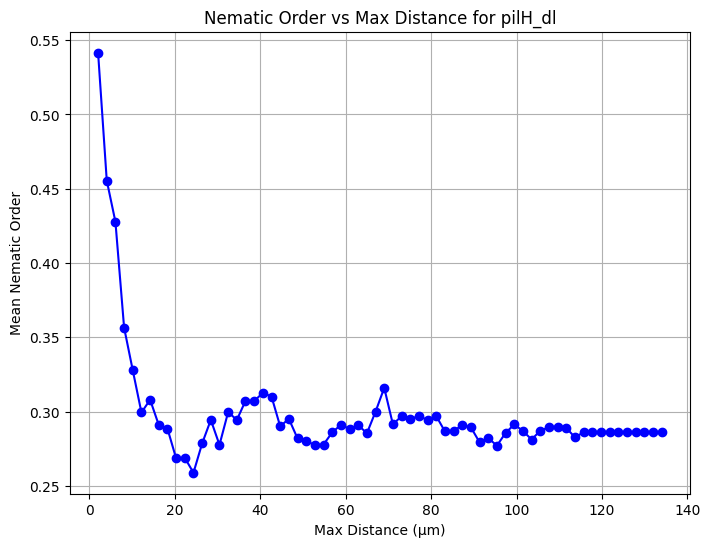

Calculating for max_distance = 0.0 µm
Calculating for max_distance = 2.0303030303030303 µm
Calculating for max_distance = 4.0606060606060606 µm
Calculating for max_distance = 6.090909090909091 µm
Calculating for max_distance = 8.121212121212121 µm
Calculating for max_distance = 10.151515151515152 µm
Calculating for max_distance = 12.181818181818182 µm
Calculating for max_distance = 14.212121212121211 µm
Calculating for max_distance = 16.242424242424242 µm
Calculating for max_distance = 18.272727272727273 µm
Calculating for max_distance = 20.303030303030305 µm
Calculating for max_distance = 22.333333333333332 µm
Calculating for max_distance = 24.363636363636363 µm
Calculating for max_distance = 26.393939393939394 µm
Calculating for max_distance = 28.424242424242422 µm
Calculating for max_distance = 30.454545454545453 µm
Calculating for max_distance = 32.484848484848484 µm
Calculating for max_distance = 34.515151515151516 µm
Calculating for max_distance = 36.54545454545455 µm
Calculating

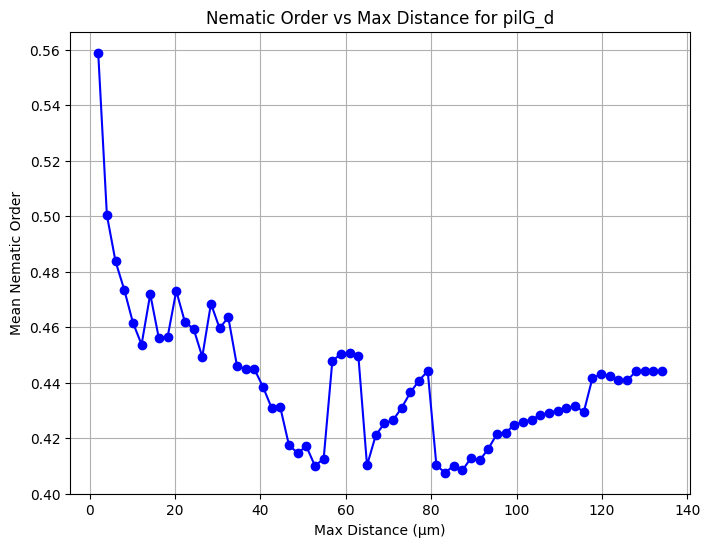

Calculating for max_distance = 0.0 µm
Calculating for max_distance = 2.0303030303030303 µm
Calculating for max_distance = 4.0606060606060606 µm
Calculating for max_distance = 6.090909090909091 µm
Calculating for max_distance = 8.121212121212121 µm
Calculating for max_distance = 10.151515151515152 µm
Calculating for max_distance = 12.181818181818182 µm
Calculating for max_distance = 14.212121212121211 µm
Calculating for max_distance = 16.242424242424242 µm
Calculating for max_distance = 18.272727272727273 µm
Calculating for max_distance = 20.303030303030305 µm
Calculating for max_distance = 22.333333333333332 µm
Calculating for max_distance = 24.363636363636363 µm
Calculating for max_distance = 26.393939393939394 µm
Calculating for max_distance = 28.424242424242422 µm
Calculating for max_distance = 30.454545454545453 µm
Calculating for max_distance = 32.484848484848484 µm
Calculating for max_distance = 34.515151515151516 µm
Calculating for max_distance = 36.54545454545455 µm
Calculating

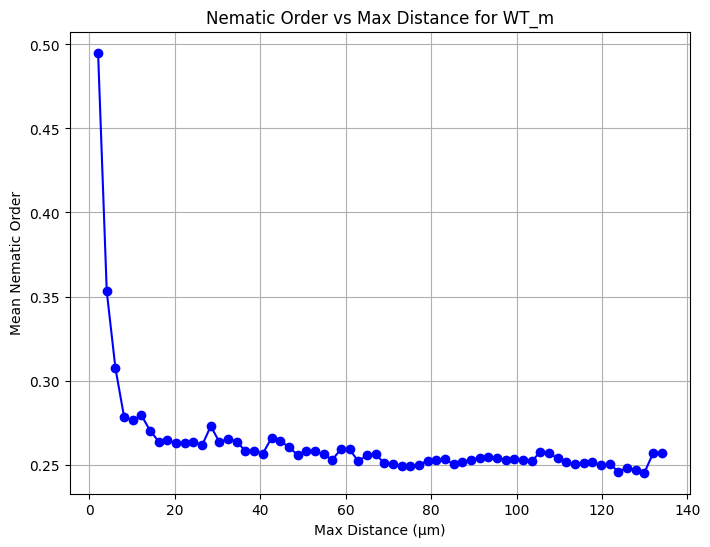

Calculating for max_distance = 0.0 µm
Calculating for max_distance = 2.0303030303030303 µm
Calculating for max_distance = 4.0606060606060606 µm
Calculating for max_distance = 6.090909090909091 µm
Calculating for max_distance = 8.121212121212121 µm
Calculating for max_distance = 10.151515151515152 µm
Calculating for max_distance = 12.181818181818182 µm
Calculating for max_distance = 14.212121212121211 µm
Calculating for max_distance = 16.242424242424242 µm
Calculating for max_distance = 18.272727272727273 µm
Calculating for max_distance = 20.303030303030305 µm
Calculating for max_distance = 22.333333333333332 µm
Calculating for max_distance = 24.363636363636363 µm
Calculating for max_distance = 26.393939393939394 µm
Calculating for max_distance = 28.424242424242422 µm
Calculating for max_distance = 30.454545454545453 µm
Calculating for max_distance = 32.484848484848484 µm
Calculating for max_distance = 34.515151515151516 µm
Calculating for max_distance = 36.54545454545455 µm
Calculating

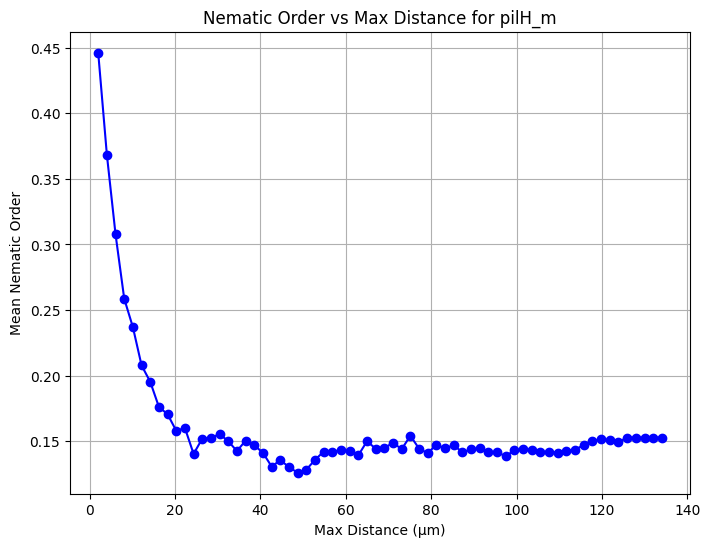

Calculating for max_distance = 0.0 µm
Calculating for max_distance = 2.0303030303030303 µm
Calculating for max_distance = 4.0606060606060606 µm
Calculating for max_distance = 6.090909090909091 µm
Calculating for max_distance = 8.121212121212121 µm
Calculating for max_distance = 10.151515151515152 µm
Calculating for max_distance = 12.181818181818182 µm
Calculating for max_distance = 14.212121212121211 µm
Calculating for max_distance = 16.242424242424242 µm
Calculating for max_distance = 18.272727272727273 µm
Calculating for max_distance = 20.303030303030305 µm
Calculating for max_distance = 22.333333333333332 µm
Calculating for max_distance = 24.363636363636363 µm
Calculating for max_distance = 26.393939393939394 µm
Calculating for max_distance = 28.424242424242422 µm
Calculating for max_distance = 30.454545454545453 µm
Calculating for max_distance = 32.484848484848484 µm
Calculating for max_distance = 34.515151515151516 µm
Calculating for max_distance = 36.54545454545455 µm
Calculating

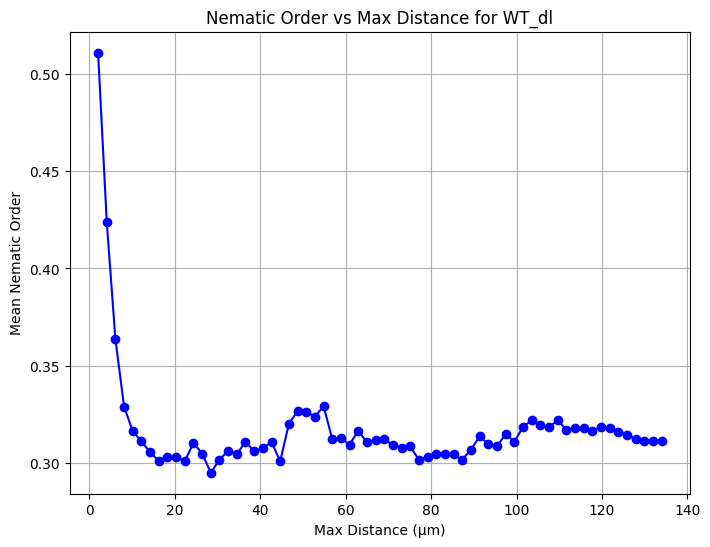

Calculating for max_distance = 0.0 µm
Calculating for max_distance = 2.0303030303030303 µm
Calculating for max_distance = 4.0606060606060606 µm
Calculating for max_distance = 6.090909090909091 µm
Calculating for max_distance = 8.121212121212121 µm
Calculating for max_distance = 10.151515151515152 µm
Calculating for max_distance = 12.181818181818182 µm
Calculating for max_distance = 14.212121212121211 µm
Calculating for max_distance = 16.242424242424242 µm
Calculating for max_distance = 18.272727272727273 µm
Calculating for max_distance = 20.303030303030305 µm
Calculating for max_distance = 22.333333333333332 µm
Calculating for max_distance = 24.363636363636363 µm
Calculating for max_distance = 26.393939393939394 µm
Calculating for max_distance = 28.424242424242422 µm
Calculating for max_distance = 30.454545454545453 µm
Calculating for max_distance = 32.484848484848484 µm
Calculating for max_distance = 34.515151515151516 µm
Calculating for max_distance = 36.54545454545455 µm
Calculating

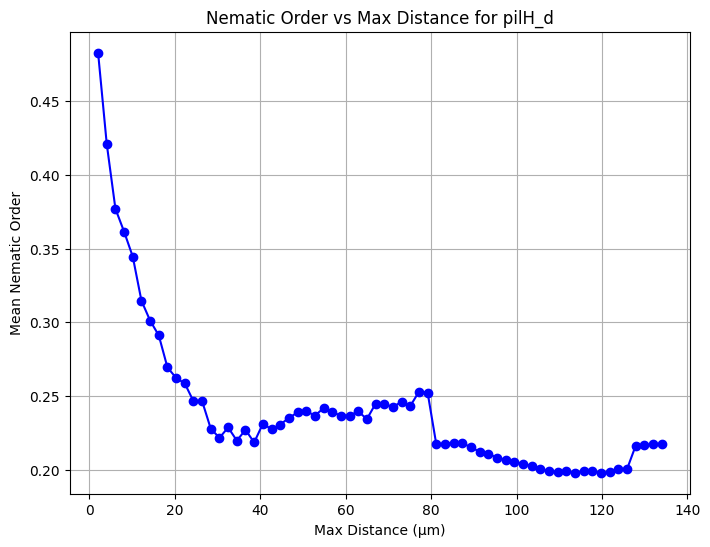

Calculating for max_distance = 0.0 µm
Calculating for max_distance = 2.0303030303030303 µm
Calculating for max_distance = 4.0606060606060606 µm
Calculating for max_distance = 6.090909090909091 µm
Calculating for max_distance = 8.121212121212121 µm
Calculating for max_distance = 10.151515151515152 µm
Calculating for max_distance = 12.181818181818182 µm
Calculating for max_distance = 14.212121212121211 µm
Calculating for max_distance = 16.242424242424242 µm
Calculating for max_distance = 18.272727272727273 µm
Calculating for max_distance = 20.303030303030305 µm
Calculating for max_distance = 22.333333333333332 µm
Calculating for max_distance = 24.363636363636363 µm
Calculating for max_distance = 26.393939393939394 µm
Calculating for max_distance = 28.424242424242422 µm
Calculating for max_distance = 30.454545454545453 µm
Calculating for max_distance = 32.484848484848484 µm
Calculating for max_distance = 34.515151515151516 µm
Calculating for max_distance = 36.54545454545455 µm
Calculating

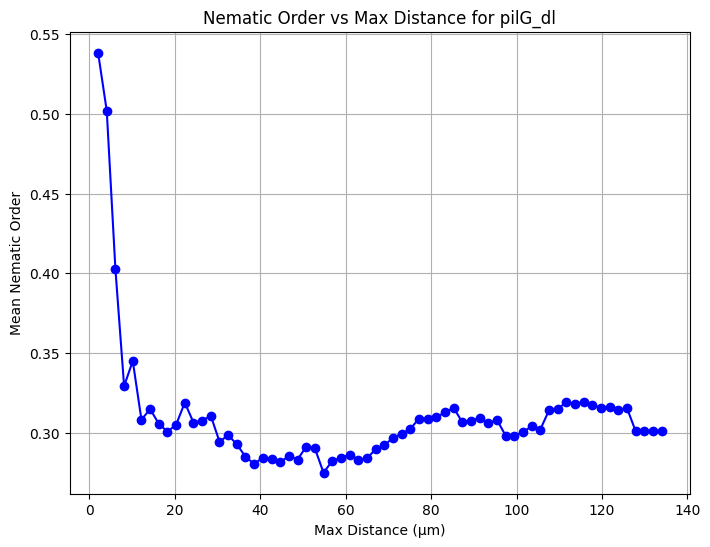

Calculating for max_distance = 0.0 µm
Calculating for max_distance = 2.0303030303030303 µm
Calculating for max_distance = 4.0606060606060606 µm
Calculating for max_distance = 6.090909090909091 µm
Calculating for max_distance = 8.121212121212121 µm
Calculating for max_distance = 10.151515151515152 µm
Calculating for max_distance = 12.181818181818182 µm
Calculating for max_distance = 14.212121212121211 µm
Calculating for max_distance = 16.242424242424242 µm
Calculating for max_distance = 18.272727272727273 µm
Calculating for max_distance = 20.303030303030305 µm
Calculating for max_distance = 22.333333333333332 µm
Calculating for max_distance = 24.363636363636363 µm
Calculating for max_distance = 26.393939393939394 µm
Calculating for max_distance = 28.424242424242422 µm
Calculating for max_distance = 30.454545454545453 µm
Calculating for max_distance = 32.484848484848484 µm
Calculating for max_distance = 34.515151515151516 µm
Calculating for max_distance = 36.54545454545455 µm
Calculating

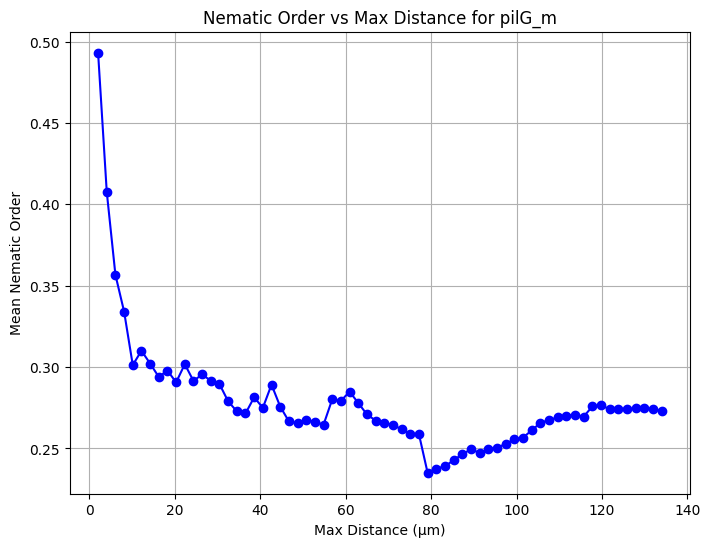

Calculating for max_distance = 0.0 µm
Calculating for max_distance = 2.0303030303030303 µm
Calculating for max_distance = 4.0606060606060606 µm
Calculating for max_distance = 6.090909090909091 µm
Calculating for max_distance = 8.121212121212121 µm
Calculating for max_distance = 10.151515151515152 µm
Calculating for max_distance = 12.181818181818182 µm
Calculating for max_distance = 14.212121212121211 µm
Calculating for max_distance = 16.242424242424242 µm
Calculating for max_distance = 18.272727272727273 µm
Calculating for max_distance = 20.303030303030305 µm
Calculating for max_distance = 22.333333333333332 µm
Calculating for max_distance = 24.363636363636363 µm
Calculating for max_distance = 26.393939393939394 µm
Calculating for max_distance = 28.424242424242422 µm
Calculating for max_distance = 30.454545454545453 µm
Calculating for max_distance = 32.484848484848484 µm
Calculating for max_distance = 34.515151515151516 µm
Calculating for max_distance = 36.54545454545455 µm
Calculating

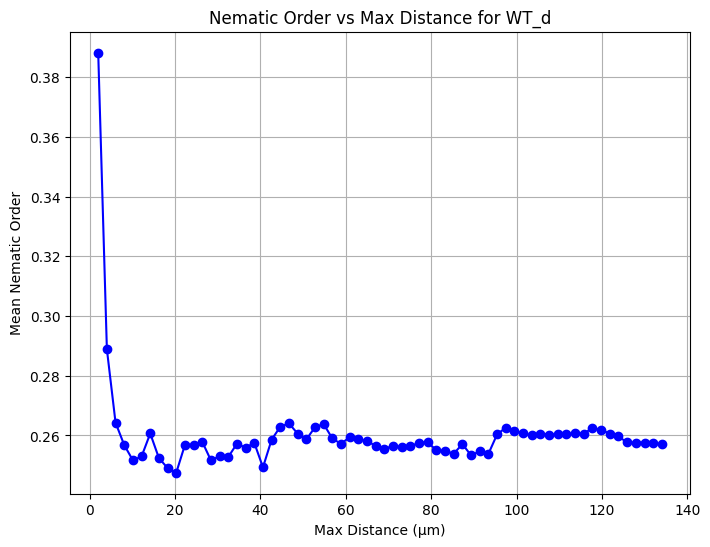

Nematic order results saved to 6_nematic_order_vs_distance.csv


In [6]:
# List to store the results for all files (if you're processing multiple files)
final_results = []

# Main part: Process each CSV file, vary max_distance, and plot results
max_distance_values = np.linspace(0, 134, num=67)  # Generate 67 distance values from 0 to 133 µm

# Loop over each CSV file, process it, and calculate nematic order for varying max_distance
for file_name in file_names:
    file_path = os.path.join(data_directory, file_name)
    
    # Read the entire file but avoid guessing data types based on partial chunks
    data = pd.read_csv(file_path, low_memory=False)

    # Ensure X, Y, T, and Theta columns are numeric, forcing non-numeric to NaN
    data['POSITION_X'] = pd.to_numeric(data['POSITION_X'], errors='coerce')
    data['POSITION_Y'] = pd.to_numeric(data['POSITION_Y'], errors='coerce')
    data['POSITION_T'] = pd.to_numeric(data['POSITION_T'], errors='coerce')
    data['ELLIPSE_THETA'] = pd.to_numeric(data['ELLIPSE_THETA'], errors='coerce')

    # Drop rows with NaN values (due to non-numeric entries)
    data = data.dropna(subset=['POSITION_X', 'POSITION_Y', 'POSITION_T', 'ELLIPSE_THETA'])

    # Calculate the nematic order for varying max_distance for a randomly selected frame
    distance_to_nematic_order, selected_frame = calculate_nematic_order_varying_distance(data, max_distance_values)
    
    # Output information about the selected frame
    print(f"Condition: {file_name}, Selected Frame: {selected_frame}")

    # Prepare results for CSV: Convert distance_to_nematic_order dictionary into a DataFrame
    results_df = pd.DataFrame({
        'Max Distance (µm)': list(distance_to_nematic_order.keys()),
        'Mean Nematic Order': list(distance_to_nematic_order.values())
    })
    results_df['Condition'] = file_name.split('.')[0]  # Add the condition name to each row
    
    # Append results to the final list
    final_results.append(results_df)

    # Plot the Nematic Order vs Distance for this file
    condition_name = file_name.split('.')[0]  # Extract condition name from the file name
    plot_nematic_order_vs_distance(distance_to_nematic_order, condition_name)

# Combine all results into a single DataFrame
final_results_df = pd.concat(final_results, ignore_index=True)

# Save the results to a CSV file
output_file = '6_nematic_order_vs_distance.csv'
final_results_df.to_csv(output_file, index=False)

print(f"Nematic order results saved to {output_file}")
